In [2]:
import torch
import torch.nn as nn
import numpy as np
import sklearn
from sklearn import datasets
from sklearn.preprocessing import StandardScaler  # for feature scaling
from sklearn.model_selection import train_test_split  # for train/test split

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sklearn.utils.validation.check_random_state(SEED)

RandomState(MT19937) at 0x7229A1E9AE40

In [9]:
X_base = torch.arange(-5, 5, 0.1).view(-1, 1)
func = -5 * X_base

y_base = func + 10 * torch.randn(X_base.size())

X_base.shape, y_base.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

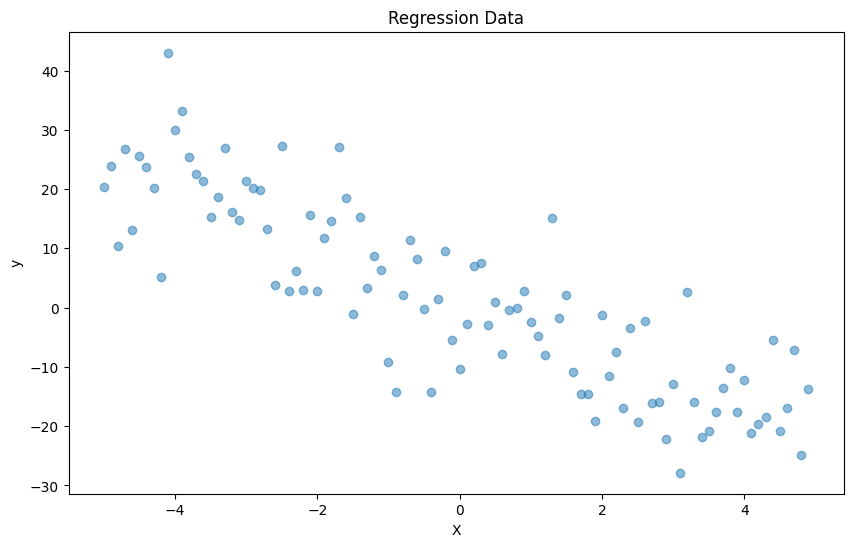

In [10]:
import matplotlib.pyplot as plt

def plot_linear_regression(X, y, model=None):
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, alpha=0.5)
    if model is not None:
        x_min = X.min()
        x_max = X.max()
        y_min = model(torch.tensor(x_min)).detach().numpy()
        y_max = model(torch.tensor(x_max)).detach().numpy()
        plt.plot([x_min, x_max], [y_min, y_max], color='red', linestyle='-')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Regression Data')

plot_linear_regression(X_base, y_base)

A = array(41.74110031) B = 2.0


/tmp/ipykernel_292729/2173918489.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_min = model(torch.tensor(x_min)).detach().numpy()
/tmp/ipykernel_292729/2173918489.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_max = model(torch.tensor(x_max)).detach().numpy()


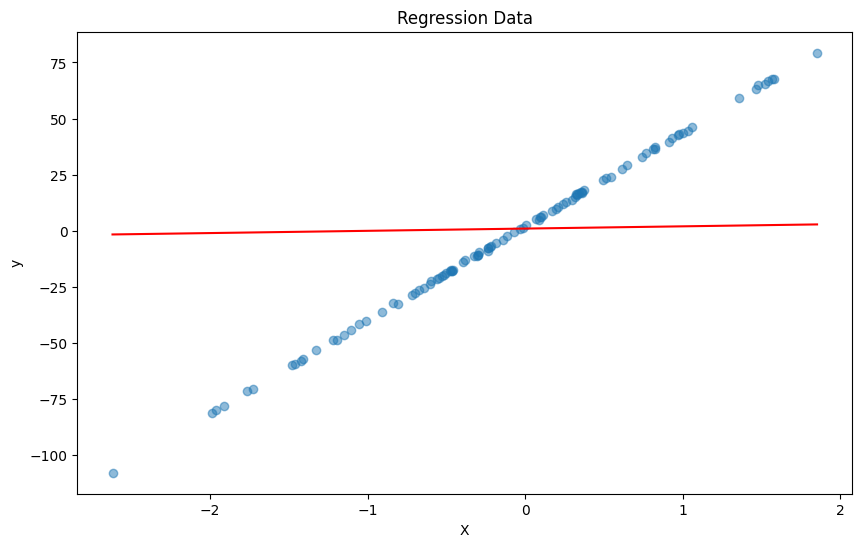

In [14]:
from sklearn.datasets import make_regression

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
sklearn.utils.validation.check_random_state(SEED)

# A = 5
B = 2.
# Generate the data

# SO WEEIIIIRD IT'S ULTRA HARD TO FIT THIS DATASET :O

X, y, A = make_regression(
    n_samples=100,
    n_features=1,
	coef=True,
	bias=B,
	noise=.5,
)

# # Add some noise to the data
# X += np.random.randn(100, 1) * 0.25
# y += np.random.randn(100)    * 0.25


X = torch.from_numpy(X.astype(np.float32))
y = torch.from_numpy(y.astype(np.float32))

X.shape, y.shape

print(f"{A = } {B = }")

a = torch.tensor(1., requires_grad=True)
b = torch.tensor(1., requires_grad=True)

plot_linear_regression(X, y, lambda x: a * x + b)

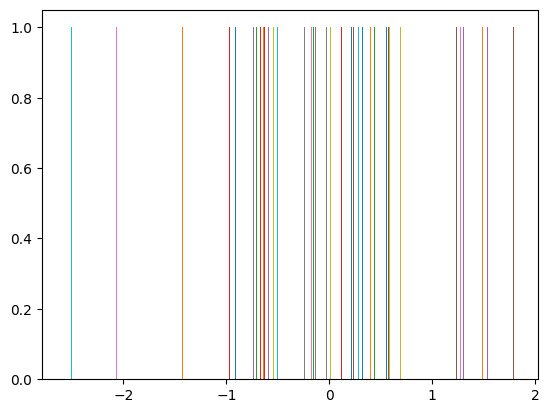

In [27]:
plt.hist(X)
# plt.hist(y)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

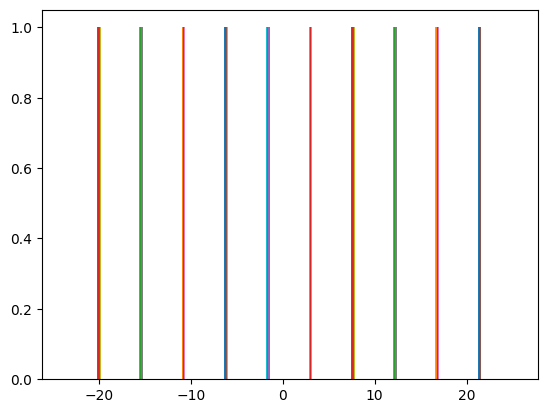

In [30]:
plt.hist(y_base)
plt.show

a = tensor(1.5455e-08, requires_grad=True) b = tensor(1., requires_grad=True)


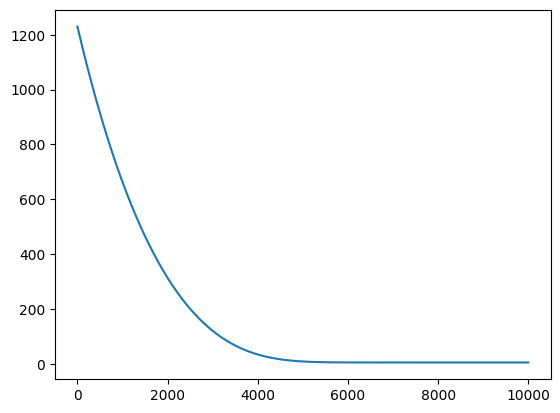

In [15]:
from torch import optim

loss_history = []
lr = 1e-2
a = torch.tensor(35., requires_grad=True)
# b = torch.tensor(1., requires_grad=True)
# optimizer = optim.Adam([a, b], lr=lr, maximize=False)
optimizer = optim.Adam([a], lr=lr, maximize=False)

from sklearn.preprocessing import StandardScaler

# Scale X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = torch.from_numpy(scaler_X.fit_transform(X.numpy()).astype(np.float32))
y = torch.from_numpy(scaler_y.fit_transform(y.numpy().reshape(-1,1)).astype(np.float32)).squeeze()


# X = X_base
# y = y_base

for i in range(10_000):
    optimizer.zero_grad()
    
    y_pred = (a * X) + 2.
    l = (y - y_pred).pow(2).mean()

    l.backward()
    optimizer.step()
    # a.data = a.data - lr * a.grad.data
    # b.data = b.data - lr * b.grad.data

    loss_history.append(l.item())
    
    # if i > 10 and max(loss_history[-50:-1]) == l:
    #     break

print(f"{a = } {b = }")
plt.plot(loss_history)

/tmp/ipykernel_292729/2173918489.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_min = model(torch.tensor(x_min)).detach().numpy()
/tmp/ipykernel_292729/2173918489.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_max = model(torch.tensor(x_max)).detach().numpy()


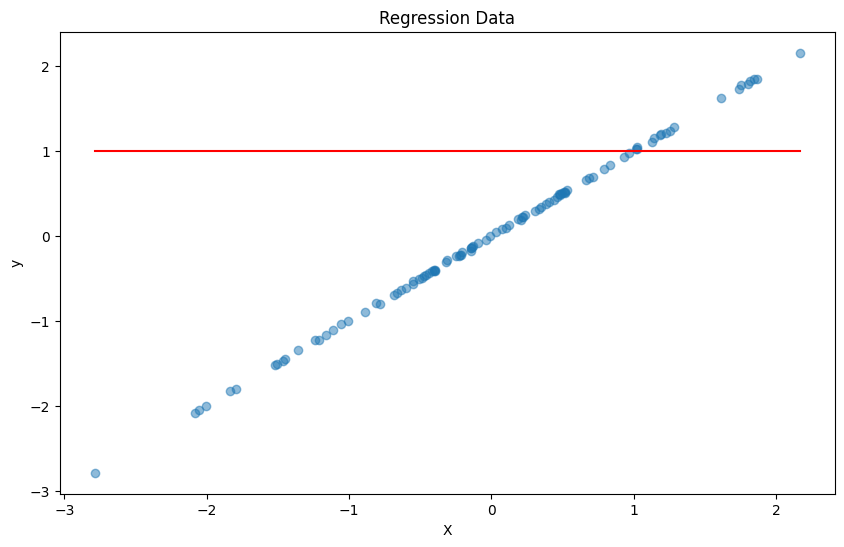

In [17]:
plot_linear_regression(X, y, lambda x: a * x + b)